In [237]:
import scanpy as scp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import pandas as pd
import bbknn
import igraph
import json

from parameters import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
adata = scp.read("results/QC.h5ad")

# Causal connection

In [3]:
bbknn.bbknn(adata,use_rep="X_pca",batch_key="Time",n_pcs=PCA,metric=METRIC,neighbors_within_batch=KNN,use_annoy=False)

In [173]:
def make_edges(a,key_stages,key_clusters,stages):

    #Make causal edge list
    m = pd.DataFrame()

    m["In"] = adata.uns["neighbors"]["distances"].nonzero()[0]
    m["Out"] = adata.uns["neighbors"]["distances"].nonzero()[1]
    m["Distances"] = np.array(adata.uns["neighbors"]["distances"][m["In"],m["Out"]])[0]
    m["Connectivities"] = np.array(adata.uns["neighbors"]["connectivities"][m["In"],m["Out"]])[0]
    m["StageIn"] = adata.obs.loc[adata.obs.iloc[m["In"]].index,key_stages].values
    m["StageOut"] = adata.obs.loc[adata.obs.iloc[m["Out"]].index,key_stages].values
    m["ClusterIn"] = adata.obs.loc[adata.obs.iloc[m["In"]].index,key_clusters].values
    m["ClusterOut"] = adata.obs.loc[adata.obs.iloc[m["Out"]].index,key_clusters].values
    m["Stage"] = [i+"_"+j for i,j in zip(m["StageIn"],m["StageOut"])]
    m["Cluster"] = [i+"_"+j for i,j in zip(m["ClusterIn"],m["ClusterOut"])]

    pos = np.array(range(adata.shape[0]))
    for i,stageIn in enumerate(stages):
        for j,stageOut in enumerate(stages):

            o0 = [i-1,i+1]
            
            if j not in o0:
                
                m = m.loc[m.loc[:,"Stage"] != (stageIn+"_"+stageOut),:]
    
    m["StageIn"] = m["StageIn"].cat.remove_unused_categories()
    m["StageOut"] = m["StageOut"].cat.remove_unused_categories()
    m["ClusterIn"] = m["ClusterIn"].cat.remove_unused_categories()
    m["ClusterOut"] = m["ClusterOut"].cat.remove_unused_categories()
    
    m["Forward"] = False
    for i,stageIn in enumerate(stages[:-1]):
        for j,stageOut in enumerate(stages[i+1:]):

                m.loc[m.loc[:,"Stage"] == (stageIn+"_"+stageOut),"Forward"] = True
                
    #Filter edges
    #Hard threshold
    
    s = m[m["Forward"].values].groupby(["ClusterIn","ClusterOut"]).size().unstack()
    s2 = m[np.invert(m["Forward"].values)].groupby(["ClusterOut","ClusterIn"]).size().unstack()

    sIn = s.transpose()
    sIn = sIn/sIn.sum(axis=0)
    sIn = sIn.transpose()

    sIn = sIn.fillna(0)

    sOut = s2.transpose()
    sOut = sOut/sOut.sum(axis=0)
    sOut = sOut.transpose()

    sOut = sOut.fillna(0)

    return {"edges":m,"forward":sIn,"backward":sOut,"stage-cluster":m[["StageIn","ClusterIn"]].drop_duplicates().set_index("ClusterIn")}    

In [174]:
edges = make_edges(adata,"Time","leiden",np.sort(adata.obs["Time"].unique()))

<AxesSubplot:xlabel='ClusterOut', ylabel='ClusterIn'>

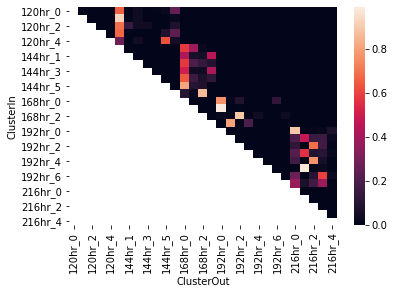

In [244]:
mask = np.triu(np.ones_like(edges["forward"], dtype=bool)).transpose()

sns.heatmap(edges["forward"],mask=mask)

# Making the database

In [234]:
def make_temporal_graph_database(adata,edges,savefolder,key_stage,key_cluster,stage_order=None,key_gene=None,gene_list=[],key_annotation=None):
    
    #Make graph
    ss = edges["backward"].values+edges["forward"].values>0
    g = igraph.Graph.Adjacency(ss)
    g.vs["cluster"] = edges["backward"].index.values
    g.vs["stage"] = [edges["stage-cluster"].loc[i,"StageIn"] for i in edges["backward"].index.values]
    if key_annotation == None:
        key_annotation = key_cluster
    g.vs["annotation"] = [adata.obs.loc[adata.obs[key_cluster]==j["cluster"],key_annotation][0] for j in g.vs]
    g.es["weightForward"] = [edges["forward"].iloc[i,j] for i,j in g.get_edgelist()]
    g.es["weightBackward"] = [edges["backward"].iloc[i,j] for i,j in g.get_edgelist()]

    if stage_order == None:
        stage_order = np.sort(adata.obs[key_stage].unique())
        
    stageInt = {j:i for i,j in enumerate(stage_order)}
    
    data = []
    for i,n in enumerate(g.vs):
        
        data_prop = {
            "id": "n_"+str(i),
            "cluster": n["cluster"],
            "annotation": n["annotation"],
            "stage": n["stage"],
            "stageInt": stageInt[n["stage"]]
          }

        if key_gene != None:
            for gene in gene_list:
                data_prop[gene] = float(adata[adata.obs[key_cluster]==n["cluster"],adata.var[key_gene]==gene].X.mean())
                l = float(adata[adata.obs[key_cluster]==n["cluster"],adata.var[key_gene]==gene].X.todense().std())
                if np.isnan(l):
                    data_prop[gene+"_std"] = 0
                else:
                    data_prop[gene+"_std"] = l

        node = {
          "data": data_prop}

        data.append(node)

    for i,n in enumerate(g.es):

        edge = {
          "data": {
            "id": "e_"+str(i),
            "source": "n_"+str(n.source),
            "target": "n_"+str(n.target),
            "weightForward": n["weightForward"],
            "weightBackward": n["weightBackward"]
          }}

        data.append(edge)

    with open(savefolder+"/time_reconstruction.json", 'w') as outfile:
        json.dump(data, outfile)       
            
    return 

def make_umap_plots_database(adata,savefolder,key_stage,key_cluster,key_plot="X_umap",stage_order=None,key_gene=None,gene_list=[]):
    
    X = adata.obsm[key_plot]
        
    stage = adata.obs[key_stage].unique()
    if len(stage)>1:
        print("Adata must have just one "+key_stage+" value")
        return
    else:
        stage = stage[0]

    data = {
        "x": [float(i) for i in X[:,0]],
        "y": [float(i) for i in X[:,1]],
        }

    #data["cluster_None"] = [5 for k in adata.obs[key_cluster]==i]
    for j in adata.obs[key_cluster].unique():
        cluster = "cluster_"+j.split("_")[-1]
        l = [5*int(k)+5 for k in adata.obs[key_cluster]==j]
        data[cluster] = l.copy()

    if key_gene != None:
        for j in gene_list:
            l = np.array(adata[:,adata.var[key_gene]==j].X.todense())
            if l.shape[1] == 0:
                data[j] = [0 for i in range(l.shape[0])]
            else:
                data[j] = [float(i) for i in l[:,0]]

    with open(savefolder+"/UMAP_"+stage+".json", 'w') as outfile:
        json.dump(data, outfile)
            
    return

In [208]:
genes = pd.read_excel("Marker_genes_scRNAseq_Gx.xlsx",header=None).values[:,0]

In [209]:
make_temporal_graph_database(adata,edges,"cytoscape/data/blood","Time","leiden",key_gene="gene_name",gene_list=genes)

In [235]:
for time in adata.obs["Time"].unique():
    adataAux = scp.read("results/dimensional_reduction_"+time+".h5ad")
    make_umap_plots_database(adataAux,"cytoscape/data/blood","Time","leiden",key_plot="X_umap",key_gene="gene_name",gene_list=genes)

['120hr']
Categories (1, object): ['120hr']
['192hr']
Categories (1, object): ['192hr']
['216hr']
Categories (1, object): ['216hr']
['144hr']
Categories (1, object): ['144hr']
['168hr']
Categories (1, object): ['168hr']
